In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("Utility_features_engineered.csv", parse_dates=["Datetime"])
df = df.set_index("Datetime").sort_index()

targets = ["Total_PowerConsumption", "F1_132KV_PowerConsumption",
           "F2_132KV_PowerConsumption", "F3_132KV_PowerConsumption"]

base_shared_features = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "is_sunday", "is_weekend", "block_of_day",
    "Temperature", "Humidity", "is_fan_on", "cooling_degree", "temp_sq",
]

cloud_features = ["CloudCover", "cloud_temp_interaction"]
holiday_features = [
    "is_holiday", "is_pre_holiday", "is_post_holiday",
    "days_to_nearest_holiday",
]

feature_variants = {
    "baseline": base_shared_features,
    "+cloud": base_shared_features + cloud_features,
    "+holidays": base_shared_features + holiday_features,
    "+cloud+holidays": base_shared_features + cloud_features + holiday_features,
}

required_features = sorted(set().union(*map(set, feature_variants.values())))
missing_features = [c for c in required_features if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing engineered features: {missing_features}. Re-run Feature_engineeering.ipynb.")

# Using the most comprehensive feature variant
shared_features = feature_variants["+cloud+holidays"]

def get_feature_cols(target):
    own_lags = [c for c in df.columns if c.startswith(f"{target}_lag")]
    own_rolls = [c for c in df.columns if c.startswith(f"{target}_roll")]
    return shared_features + own_lags + own_rolls

In [3]:
test_start = df.index.max() - pd.Timedelta(days=42)
validation_start = test_start - pd.Timedelta(days=28)
fit_df = df[df.index <= validation_start]
validation_df = df[(df.index > validation_start) & (df.index <= test_start)]
train_df = df[df.index <= test_start]
test_df = df[df.index > test_start]
print(f"Fit: {len(fit_df)} | Validation: {len(validation_df)} | "
      f"Final train: {len(train_df)} | Test: {len(test_df)}")

Fit: 41328 | Validation: 4032 | Final train: 45360 | Test: 6048


In [4]:
default_params = {
    "objective": "regression", "metric": "mae", "device_type": "cpu",
    "learning_rate": 0.05, "num_leaves": 64, "min_data_in_leaf": 50,
    "feature_fraction": 0.9, "bagging_fraction": 0.8, "bagging_freq": 5,
    "n_estimators": 1000, "random_state": 42, "verbose": -1,
}

# F3 Optuna parameters override the shared defaults while preserving training controls.
f3_tuned_params = {
"objective": "regression", "metric": "mae", "device_type": "cpu",
'learning_rate': 0.03220219001068644, 'num_leaves': 71, 'max_depth': 4,
'min_data_in_leaf': 78, 'feature_fraction': 0.9993528456592569, 'bagging_fraction': 0.946520089180267,
'bagging_freq': 7, 'lambda_l1': 0.0341693961913318, 'lambda_l2': 0.0013621858075783563
}

f3_params = {**default_params, **f3_tuned_params}

params_per_target = {
    "Total_PowerConsumption": default_params,
    "F1_132KV_PowerConsumption": default_params,
    "F2_132KV_PowerConsumption": default_params,
    "F3_132KV_PowerConsumption": f3_params,
}

In [5]:
models = {}
feature_cols_per_target = {}
results = {}

for target in targets:
    print(f"\nTraining {target}...")
    feature_cols = get_feature_cols(target)
    feature_cols_per_target[target] = feature_cols

    X_train, y_train = train_df[feature_cols], train_df[target]
    X_test, y_test = test_df[feature_cols], test_df[target]

    model = lgb.LGBMRegressor(**params_per_target[target])
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    models[target] = model

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    results[target] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}
    print(f"{target}: MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

print("\n=== Final Results ===")
pd.DataFrame(results).T


Training Total_PowerConsumption...
Total_PowerConsumption: MAE=377.30  RMSE=558.83  MAPE=0.62%

Training F1_132KV_PowerConsumption...
F1_132KV_PowerConsumption: MAE=217.02  RMSE=326.79  MAPE=0.79%

Training F2_132KV_PowerConsumption...
F2_132KV_PowerConsumption: MAE=177.90  RMSE=275.42  MAPE=0.77%

Training F3_132KV_PowerConsumption...
F3_132KV_PowerConsumption: MAE=208.43  RMSE=314.49  MAPE=2.11%

=== Final Results ===


,MAE,RMSE,MAPE
Total_PowerConsumption,377.300938,558.834886,0.620344
F1_132KV_PowerConsumption,217.018448,326.791816,0.785211
F2_132KV_PowerConsumption,177.899914,275.417876,0.766884
F3_132KV_PowerConsumption,208.432433,314.485306,2.108889


In [6]:
for target, model in models.items():
    joblib.dump(model, f"model_{target}.pkl")

joblib.dump(feature_cols_per_target, "feature_cols_per_target.pkl")
joblib.dump(targets, "targets.pkl")

print("All 4 models + feature column metadata saved.")

All 4 models + feature column metadata saved.


In [7]:
import joblib

feature_cols_per_target = joblib.load("feature_cols_per_target.pkl")
models = {t: joblib.load(f"model_{t}.pkl") for t in targets}

results_df = test_df[targets].copy()
for t in targets:
    X_test = test_df[feature_cols_per_target[t]]
    results_df[f"{t}_pred"] = models[t].predict(X_test)

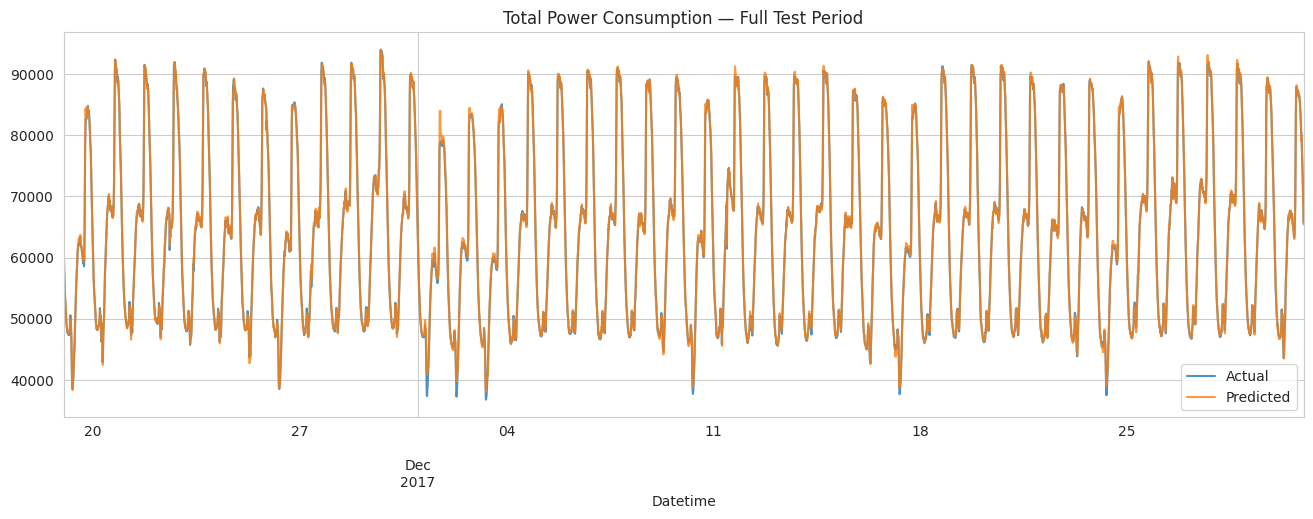

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
results_df["Total_PowerConsumption"].plot(ax=ax, label="Actual", alpha=0.8)
results_df["Total_PowerConsumption_pred"].plot(ax=ax, label="Predicted", alpha=0.8)
ax.set_title("Total Power Consumption — Full Test Period")
ax.legend()
plt.show()

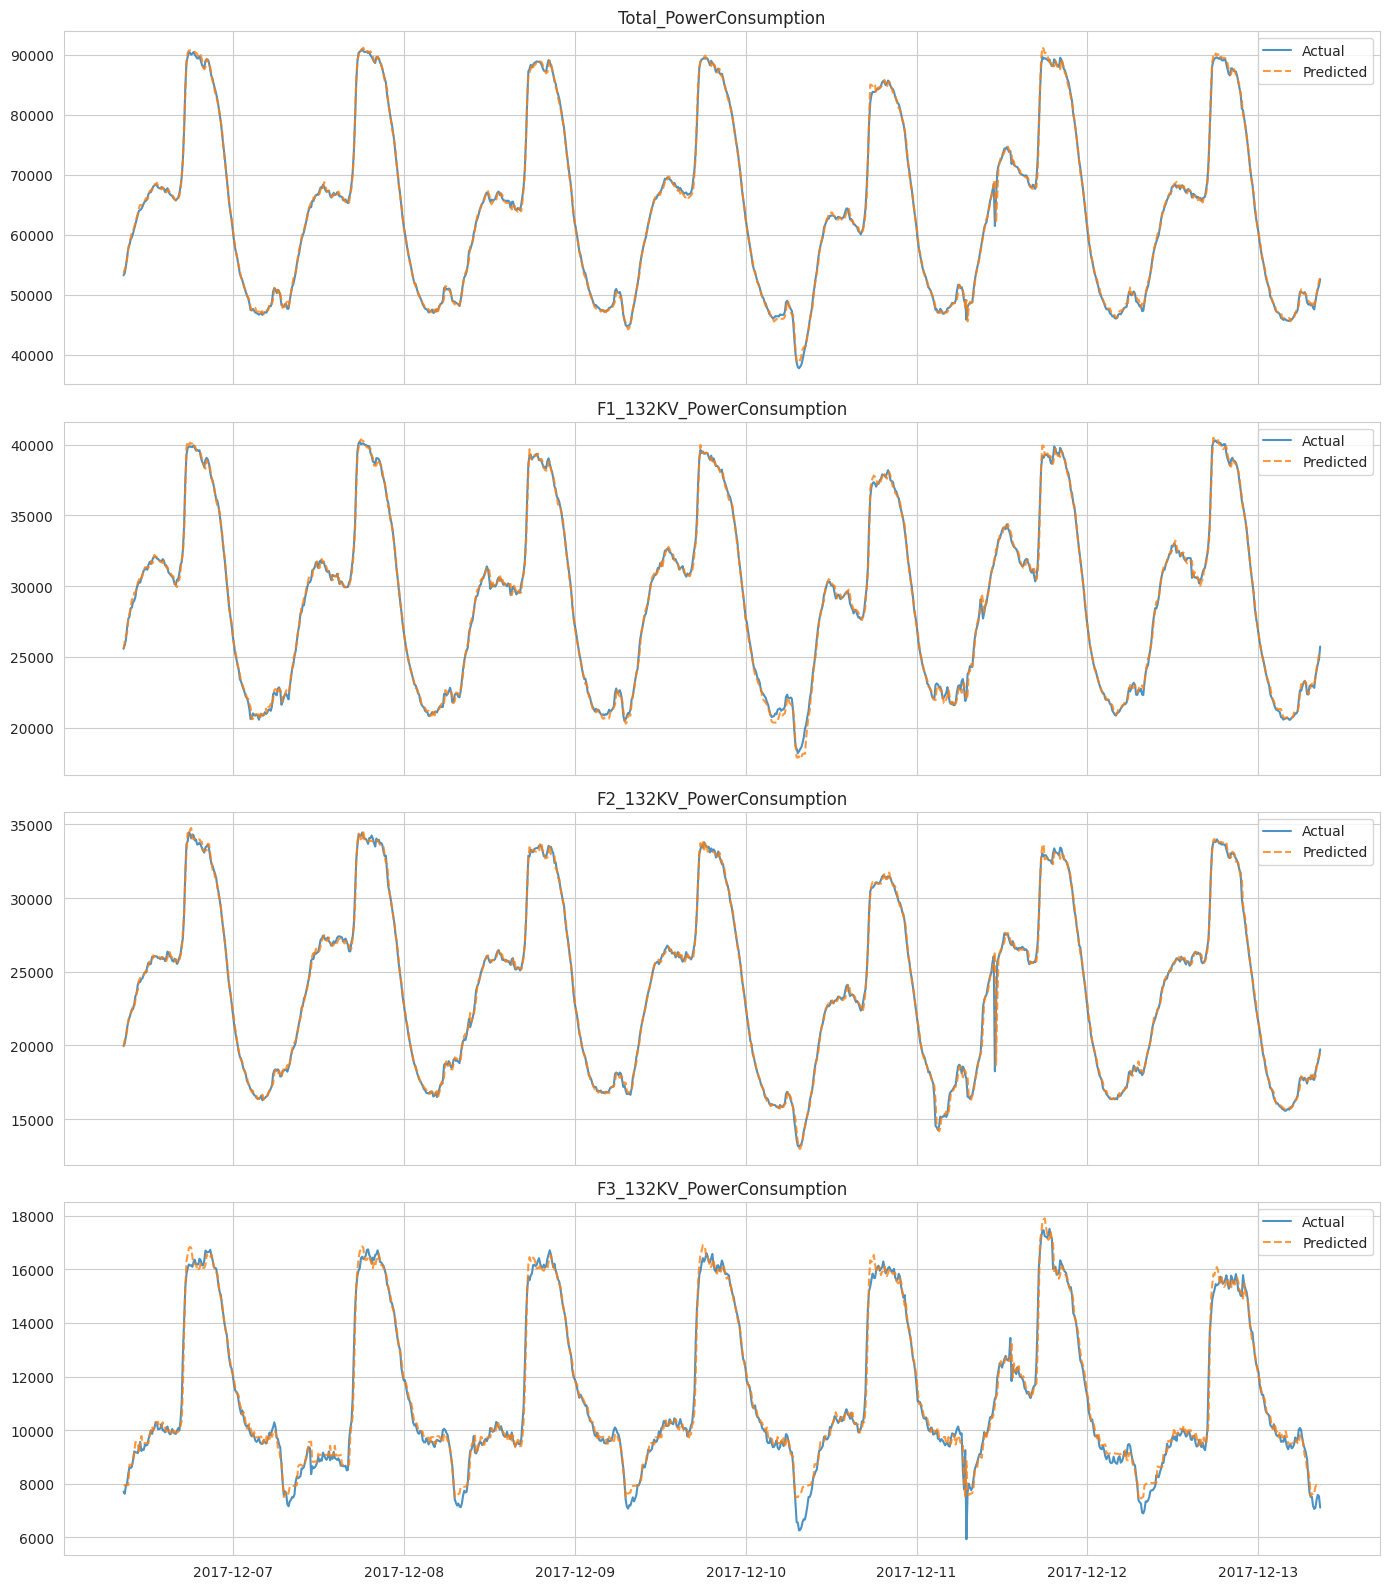

In [9]:
week_start = test_df.index[2500]   # change this index to inspect different weeks
week_end = week_start + pd.Timedelta(days=7)
week_data = results_df.loc[week_start:week_end]

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
for i, t in enumerate(targets):
    axes[i].plot(week_data.index, week_data[t], label="Actual", alpha=0.8)
    axes[i].plot(week_data.index, week_data[f"{t}_pred"], label="Predicted", alpha=0.8, linestyle="--")
    axes[i].set_title(t)
    axes[i].legend()
plt.tight_layout()
plt.show()

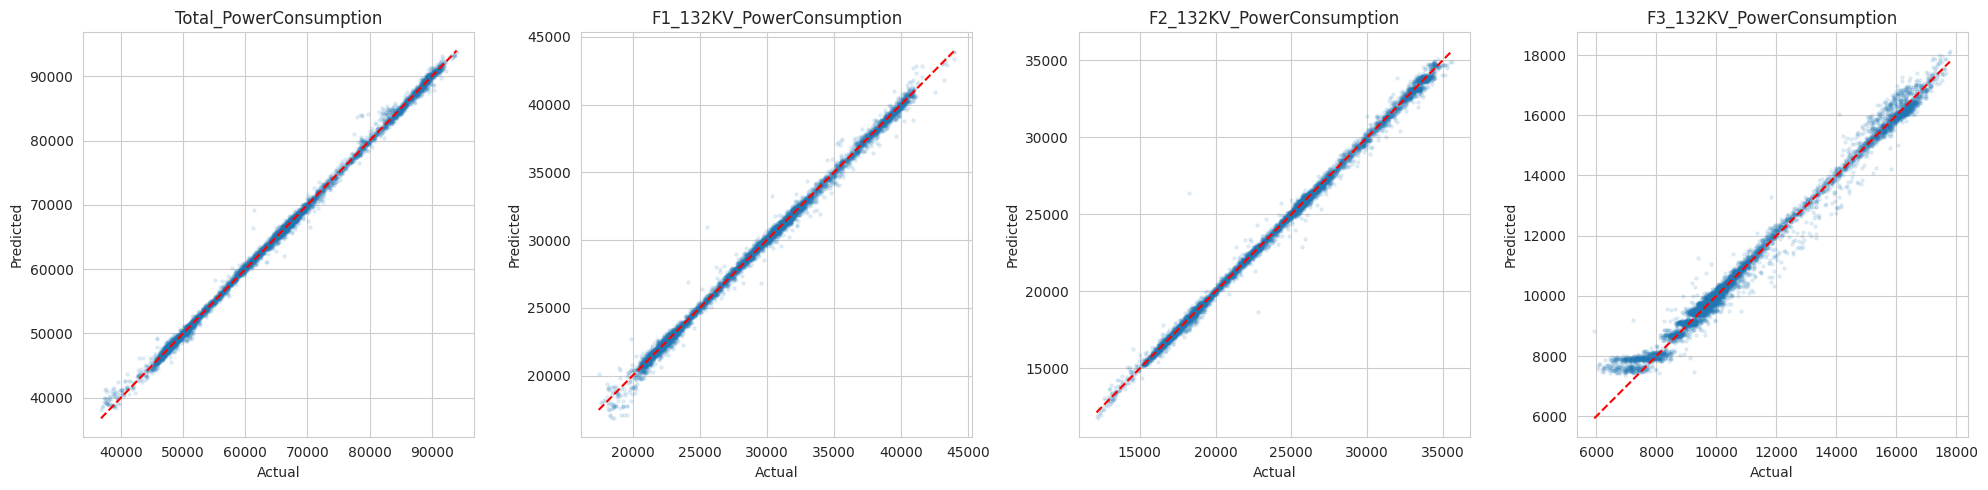

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, t in enumerate(targets):
    axes[i].scatter(results_df[t], results_df[f"{t}_pred"], alpha=0.1, s=5)
    minv, maxv = results_df[t].min(), results_df[t].max()
    axes[i].plot([minv, maxv], [minv, maxv], color="red", linestyle="--")
    axes[i].set_title(t)
    axes[i].set_xlabel("Actual"); axes[i].set_ylabel("Predicted")
plt.tight_layout()
plt.show()

In [11]:
import os
import zipfile
from google.colab import files

model_files = [
    "model_Total_PowerConsumption.pkl",
    "model_F1_132KV_PowerConsumption.pkl",
    "model_F2_132KV_PowerConsumption.pkl",
    "model_F3_132KV_PowerConsumption.pkl",
    "feature_cols_per_target.pkl",
    "targets.pkl",
]

with zipfile.ZipFile("trained_models_bundle.zip", "w") as zf:
    for f in model_files:
        if os.path.exists(f):
            zf.write(f)
        else:
            print(f"Warning: {f} not found, skipping")

files.download("trained_models_bundle.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>